In [323]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path

# Load NAV data from processed database OR use nav_df from previous notebook
nav_df = None

# Option 1: Try to load from processed_data.db
nav_path = Path(r"C:\Users\Asus\OneDrive\Desktop\Bluestock_intern\Bluestock-project-repo-1\bluestock_mf_capstone\data\processed\nav_history_cleaned.csv")
if nav_path.exists():
    try:
        nav_df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\Bluestock_intern\Bluestock-project-repo-1\bluestock_mf_capstone\data\processed\nav_history_cleaned.csv", parse_dates=['date'])

    except Exception as e:
        print(f"Could not load from {nav_path}: {e}")
        nav_df = None

# Option 2: Use nav_df from previous notebook (03_EDA_analysis)
if nav_df is None and "nav_df" in globals():
    nav_df = nav_df.copy()
    if 'Date' in nav_df.columns:
        nav_df.set_index('Date', inplace=True)
    print(f"Using nav_df from previous notebook: {nav_df.shape}")


# Validate nav_df
if nav_df is None or nav_df.empty:
    raise ValueError("Could not load or generate NAV data. Check processed_data.db or run 03_EDA_analysis first.")

print(f"\n NAV DataFrame ready: {nav_df.shape[0]} trading days, {nav_df['amfi_code'].nunique()} schemes")




 NAV DataFrame ready: 64320 trading days, 40 schemes


In [324]:
nav_df


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
...,...,...,...
64315,149324,2026-05-25,292.4810
64316,149324,2026-05-26,291.2707
64317,149324,2026-05-27,288.8007
64318,149324,2026-05-28,280.6873


In [325]:
amfi_list = nav_df['amfi_code'].unique().tolist()
print(len(amfi_list))


40


In [326]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64320 entries, 0 to 64319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  64320 non-null  int64         
 1   date       64320 non-null  datetime64[us]
 2   nav        64320 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.5 MB


In [327]:
for amfi in amfi_list:
    if (nav_df['amfi_code'] == amfi).any():
        nav_df['daily_return'] = (nav_df['nav'] - nav_df['nav'].shift(1))/nav_df['nav'].shift(1)

mask = (
    (nav_df['amfi_code'] != nav_df['amfi_code'].shift(1))
    & nav_df['amfi_code'].shift(1).notna()
)

nav_df.loc[mask, 'daily_return'] = np.nan

nav_df.head(10)


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-08,515.1639,0.000000
6,100016,2022-01-09,515.1639,0.000000
7,100016,2022-01-10,510.7136,-0.008639
8,100016,2022-01-11,513.5542,0.005562
9,100016,2022-01-12,512.3195,-0.002404


In [328]:
nav_df.isna().sum()

amfi_code        0
date             0
nav              0
daily_return    40
dtype: int64

In [329]:
nav_df.fillna(0, inplace=True)
nav_df.isna().sum()

amfi_code       0
date            0
nav             0
daily_return    0
dtype: int64

In [330]:
nav_1y = nav_df[['amfi_code','date','nav']].rename(
    columns={'date':'date_plus_1y', 'nav':'nav_1y_back'}
)

nav_1y['date_plus_1y'] += pd.DateOffset(years=1)

nav_df = nav_df.merge(
    nav_1y,
    left_on=['amfi_code', 'date'],
    right_on=['amfi_code', 'date_plus_1y'],
    how='left'
)


In [331]:
nav_3y = nav_df[['amfi_code','date','nav']].rename(
    columns={'date':'date_plus_3y', 'nav':'nav_3y_back'}
)

nav_3y['date_plus_3y'] += pd.DateOffset(years=3)

nav_df = nav_df.merge(
    nav_3y,
    left_on=['amfi_code', 'date'],
    right_on=['amfi_code', 'date_plus_3y'],
    how='left'
)


In [332]:
nav_5y = nav_df[['amfi_code','date','nav']].rename(
    columns={'date':'date_plus_5y', 'nav':'nav_5y_back'}
)

nav_5y['date_plus_5y'] += pd.DateOffset(years=5)

nav_df = nav_df.merge(
    nav_5y,
    left_on=['amfi_code', 'date'],
    right_on=['amfi_code', 'date_plus_5y'],
    how='left'
)


In [333]:
nav_df.sample(10)

,amfi_code,date,nav,daily_return,date_plus_1y,nav_1y_back,date_plus_3y,nav_3y_back,date_plus_5y,nav_5y_back
42727,120506,2024-06-14,255.4192,-0.013276,2024-06-14,249.6788,NaT,NaN,NaT,NaN
21293,118636,2023-01-14,33.6003,0.000000,2023-01-14,30.2775,NaT,NaN,NaT,NaN
59320,148569,2025-10-29,71.0141,0.017642,2025-10-29,58.8061,2025-10-29,36.4701,NaT,NaN
13777,102887,2024-06-26,245.6123,0.002702,2024-06-26,187.9244,NaT,NaN,NaT,NaN
30714,119551,2022-05-26,50.7535,-0.006538,NaT,NaN,NaT,NaN,NaT,NaN
2547,100025,2024-07-29,28.9516,0.001685,2024-07-29,27.5108,NaT,NaN,NaT,NaN
7986,101207,2026-04-01,61.6463,0.000182,2026-04-01,71.9544,2026-04-01,51.7173,NaT,NaN
8431,101208,2023-01-24,334.3618,0.000382,2023-01-24,312.1926,NaT,NaN,NaT,NaN
45696,120841,2023-10-09,354.3844,-0.007233,2023-10-09,267.1687,NaT,NaN,NaT,NaN
5709,101206,2024-06-03,446.3145,-0.003969,2024-06-03,353.1846,NaT,NaN,NaT,NaN


In [334]:
nav_df.drop(columns=['date_plus_1y', 'date_plus_3y', 'date_plus_5y'], inplace=True)
print(nav_df.shape)
nav_df.isna().sum()

(64360, 7)


amfi_code           0
date                0
nav                 0
daily_return        0
nav_1y_back     14640
nav_3y_back     43840
nav_5y_back     64360
dtype: int64

In [335]:
nav_df['cagr_1y'] = (nav_df["nav"] - nav_df['nav_1y_back']) ** (1/1) - 1
nav_df['cagr_3y'] = (nav_df["nav"] - nav_df['nav_3y_back']) ** (1/3) - 1
nav_df['cagr_5y'] = (nav_df["nav"] - nav_df['nav_5y_back']) ** (1/5) - 1
nav_df.head(10)

,amfi_code,date,nav,daily_return,nav_1y_back,nav_3y_back,nav_5y_back,cagr_1y,cagr_3y,cagr_5y
0,100016,2022-01-03,520.4608,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN,NaN,NaN,NaN
5,100016,2022-01-08,515.1639,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
6,100016,2022-01-09,515.1639,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
7,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN,NaN,NaN,NaN
8,100016,2022-01-11,513.5542,0.005562,NaN,NaN,NaN,NaN,NaN,NaN
9,100016,2022-01-12,512.3195,-0.002404,NaN,NaN,NaN,NaN,NaN,NaN


In [336]:
cagr_comparison_table = nav_df.copy().fillna(0)
cagr_comparison_table = cagr_comparison_table.sort_values(['cagr_1y', 'cagr_3y', 'cagr_5y'], ascending=True)
cagr_comparison_table.head(10)

,amfi_code,date,nav,daily_return,nav_1y_back,nav_3y_back,nav_5y_back,cagr_1y,cagr_3y,cagr_5y
52576,125497,2024-12-26,734.7568,-0.005653,851.3554,0.0000,0.0,-117.5986,0.000000,0.0
52578,125497,2024-12-28,729.4797,0.000000,845.2615,0.0000,0.0,-116.7818,0.000000,0.0
52577,125497,2024-12-27,729.4797,-0.007182,844.9740,0.0000,0.0,-116.4943,0.000000,0.0
52581,125497,2024-12-31,728.4784,-0.006567,843.8509,0.0000,0.0,-116.3725,0.000000,0.0
52579,125497,2024-12-29,729.4797,0.000000,843.8509,0.0000,0.0,-115.3712,0.000000,0.0
52582,125497,2025-01-01,727.4728,-0.001380,841.1031,0.0000,0.0,-114.6303,0.000000,0.0
52580,125497,2024-12-30,733.2936,0.005228,843.8509,0.0000,0.0,-111.5573,0.000000,0.0
52575,125497,2024-12-25,738.9340,-0.030760,845.0679,0.0000,0.0,-107.1339,0.000000,0.0
52583,125497,2025-01-02,737.8158,0.014218,841.4595,0.0000,0.0,-104.6437,0.000000,0.0
52585,125497,2025-01-04,744.6984,0.000000,841.5485,560.7052,0.0,-97.8501,4.687664,0.0


In [337]:
nav_df['sharpe_ratio_perday'] = ((nav_df['daily_return'] - 0.065) / nav_df['daily_return'].std())*(252**0.5)
nav_df.sample(10)


,amfi_code,date,nav,daily_return,nav_1y_back,nav_3y_back,nav_5y_back,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio_perday
28275,119095,2024-07-13,72.7916,0.000000,78.1626,NaN,NaN,-6.3710,NaN,NaN,-118.544734
2718,100025,2025-01-16,29.6359,0.003681,28.4985,26.3194,NaN,0.1374,0.491283,NaN,-111.830814
39240,120504,2023-09-19,87.9478,0.014362,72.0464,NaN,NaN,14.9014,NaN,NaN,-92.352298
34267,119598,2023-04-26,158.3986,-0.012399,105.1714,NaN,NaN,52.2272,NaN,NaN,-141.157133
10359,102885,2023-12-09,130.2680,0.000000,101.6994,NaN,NaN,27.5686,NaN,NaN,-118.544734
62446,149323,2025-07-29,212.6703,-0.006881,140.7706,85.1168,NaN,70.8997,4.033817,NaN,-131.093862
49971,120844,2022-04-05,3255.9343,0.000275,NaN,NaN,NaN,NaN,NaN,NaN,-118.042939
59338,148569,2025-11-16,73.4283,0.000000,61.4793,37.4988,NaN,10.9490,2.299770,NaN,-118.544734
9762,102885,2022-04-21,89.0309,0.000458,NaN,NaN,NaN,NaN,NaN,NaN,-117.708578
6586,101207,2022-06-02,36.9994,0.002653,NaN,NaN,NaN,NaN,NaN,NaN,-113.706269


In [338]:
sharpe_df = (
    nav_df
    .groupby('amfi_code')['daily_return']
    .agg(
        mean_return='mean',
        std_return='std'
    )
)

rf_daily = 0.065 / 252

sharpe_df['sharpe'] = (
    (sharpe_df['mean_return'] - rf_daily)
    / sharpe_df['std_return']
) * np.sqrt(252)

In [339]:
sharpe_df['amfi_code'] = sharpe_df.index
sharpe_df.reset_index(drop=True, inplace=True)
sharpe_df.sort_values('sharpe', ascending=False).head(10)

,mean_return,std_return,sharpe,amfi_code
34,0.000770,0.007571,1.074198,148567
30,0.000769,0.008472,0.957251,120843
36,0.000816,0.009435,0.939142,148569
25,0.000816,0.010296,0.860418,120505
19,0.000653,0.007326,0.855075,119551
38,0.000757,0.009458,0.837615,149323
2,0.000775,0.010092,0.813285,100033
9,0.000615,0.007542,0.750645,118632
3,0.000617,0.007771,0.733679,101206
39,0.000863,0.013239,0.725769,149324


In [340]:
nav_df['downside_return'] = nav_df['daily_return'].apply(lambda x: x if x < 0 else 0)
nav_df['sortino_ratio_perday'] = ((nav_df['daily_return'] - 0.065) / nav_df['downside_return'].std())*(252**0.5)
nav_df.sample(5)

,amfi_code,date,nav,daily_return,nav_1y_back,nav_3y_back,nav_5y_back,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio_perday,downside_return,sortino_ratio_perday
20239,118635,2024-07-22,224.5474,-0.001093,211.4060,NaN,NaN,12.1414,NaN,NaN,-120.538119,-0.001093,-198.494104
43866,120507,2023-03-02,308.8330,0.000768,289.4622,NaN,NaN,18.3708,NaN,NaN,-117.143501,0.000000,-192.904075
37885,120503,2024-05-30,93.0031,0.010920,79.7873,NaN,NaN,12.2158,NaN,NaN,-98.629687,0.000000,-162.416765
42919,120506,2024-12-23,266.9190,-0.007442,267.1914,NaN,NaN,-1.2724,NaN,NaN,-132.116488,-0.007442,-217.560587
19130,118634,2025-12-03,109.6029,-0.033517,106.8577,88.4629,NaN,1.7452,1.765042,NaN,-179.672537,-0.033517,-295.872706


In [341]:
benchmark_df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\Bluestock_intern\Bluestock-project-repo-1\bluestock_mf_capstone\data\processed\benchmark_indices_cleaned.csv")

In [342]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [343]:
from scipy.stats import linregress
import pandas as pd
import numpy as np



benchmark_wide = (
    benchmark_df
    .pivot(
        index='date',
        columns='index_name',
        values='close_value'
    )
    .reset_index()
)
benchmark_wide['date'] = pd.to_datetime(benchmark_wide['date'])
benchmark_wide.head()

index_name,date,BSE_SMALLCAP,CRISIL_GILT,CRISIL_LIQUID,NIFTY100,NIFTY50,NIFTY500,NIFTY_MIDCAP150
0,2022-01-03,26554.60,1451.06,2281.51,17778.24,17492.79,14837.07,9721.79
1,2022-01-04,27079.92,1453.26,2281.61,17537.52,17689.64,14743.12,9954.23
2,2022-01-05,27313.35,1455.50,2282.31,17607.73,17835.05,14960.53,9859.05
3,2022-01-06,27377.05,1454.41,2282.91,17556.05,17878.51,14950.28,9787.54
4,2022-01-07,26316.86,1454.33,2284.78,17664.02,17759.15,15044.47,9803.31


In [344]:
benchmark_wide['nifty100_return'] = (
    benchmark_wide['NIFTY100']
    .pct_change()
)

benchmark_wide['nifty50_return'] = (
    benchmark_wide['NIFTY50']
    .pct_change()
)

benchmark_wide = benchmark_wide[
    ['date', 'nifty50_return', 'nifty100_return']
]

In [345]:
alpha_beta_data = nav_df[
    ['amfi_code', 'date', 'daily_return']
].merge(
    benchmark_wide,
    on='date',
    how='inner'
)

In [346]:
alpha_beta_data.head()

,amfi_code,date,daily_return,nifty50_return,nifty100_return
0,100016,2022-01-03,0.000000,NaN,NaN
1,100016,2022-01-04,-0.010306,0.011253,-0.013540
2,100016,2022-01-05,0.012865,0.008220,0.004003
3,100016,2022-01-06,-0.011377,0.002437,-0.002935
4,100016,2022-01-07,-0.001210,-0.006676,0.006150


In [347]:
rows = []

for amfi_code, group in alpha_beta_data.groupby('amfi_code'):

    row = {'amfi_code': amfi_code}

    # Nifty 50
    temp = group[
        ['daily_return', 'nifty50_return']
    ].dropna()

    if len(temp) > 1:

        res = linregress(
            temp['nifty50_return'],
            temp['daily_return']
        )

        row['alpha_nifty50'] = res.intercept * 252
        row['beta_nifty50'] = res.slope

    rows.append(row)

    # Nifty 100
    temp = group[
        ['daily_return', 'nifty100_return']
    ].dropna()

    if len(temp) > 1:

        res = linregress(
            temp['nifty100_return'],
            temp['daily_return']
        )

        row['alpha_nifty100'] = res.intercept * 252
        row['beta_nifty100'] = res.slope

    rows.append(row)


alpha_beta_df = pd.DataFrame(rows)

In [348]:
alpha_beta_df.head()

,amfi_code,alpha_nifty50,beta_nifty50,alpha_nifty100,beta_nifty100
0,100016,0.036600,-0.025955,0.037708,-0.058442
1,100016,0.036600,-0.025955,0.037708,-0.058442
2,100025,0.043574,-0.016222,0.043220,0.000859
3,100025,0.043574,-0.016222,0.043220,0.000859
4,100033,0.273471,-0.011335,0.273123,0.004233


In [349]:
alpha_beta_df.isna().sum()

amfi_code         0
alpha_nifty50     0
beta_nifty50      0
alpha_nifty100    0
beta_nifty100     0
dtype: int64

In [350]:
alpha_beta_df.to_csv(r"C:\Users\Asus\OneDrive\Desktop\Bluestock_intern\Bluestock-project-repo-1\bluestock_mf_capstone\data\processed\alpha_beta_data.csv", index=False)

In [351]:
nav_df['running_max'] = (nav_df.groupby('amfi_code')['nav'].cummax())

nav_df['drawdown'] = (nav_df['nav'] / nav_df['running_max']) - 1

mdd_df = (nav_df.groupby('amfi_code')['drawdown'].min().reset_index(name='max_drawdown'))



In [352]:
rows = []

for amfi_code, g in nav_df.groupby('amfi_code'):

    g = g.sort_values('date')

    trough_idx = g['drawdown'].idxmin()

    trough_date = g.loc[trough_idx, 'date']
    trough_nav = g.loc[trough_idx, 'nav']

    peak_nav = g.loc[trough_idx, 'running_max']

    peak_idx = g.loc[:trough_idx][
        g.loc[:trough_idx, 'nav'] == peak_nav
    ].index[0]

    peak_date = g.loc[peak_idx, 'date']

    rows.append({
        'amfi_code': amfi_code,
        'peak_date': peak_date,
        'trough_date': trough_date,
        'max_drawdown': g.loc[trough_idx, 'drawdown']
    })

mdd_periods_df = pd.DataFrame(rows)

In [353]:
mdd_periods_df.head()

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [354]:
expense_df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\Bluestock_intern\Bluestock-project-repo-1\bluestock_mf_capstone\data\processed\scheme_performance_cleaned.csv")
expense_df = expense_df[['amfi_code', 'expense_ratio_pct']]
print(expense_df.head())
print(expense_df['expense_ratio_pct'].describe())

   amfi_code  expense_ratio_pct
0     119551               1.54
1     119552               0.66
2     119598               1.43
3     119599               0.72
4     119120               0.77
count    40.000000
mean      1.237000
std       0.386584
min       0.550000
25%       0.787500
50%       1.425000
75%       1.540000
max       1.640000
Name: expense_ratio_pct, dtype: float64


In [355]:
scorecard = (
    nav_df
    .sort_values('date')
    .groupby('amfi_code')
    .tail(1)
    [['amfi_code', 'cagr_3y']]
)

scorecard = scorecard.merge(
    sharpe_df[['amfi_code', 'sharpe']],
    on='amfi_code',
    how='left'
)

scorecard.rename(
    columns={'sharpe': 'sharpe_ratio'},
    inplace=True
)

scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code', 'alpha_nifty100']],
    on='amfi_code',
    how='left'
)

scorecard.rename(
    columns={'alpha_nifty100': 'alpha'},
    inplace=True
)

scorecard = scorecard.merge(
    expense_df[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code',
    how='left'
)

scorecard.rename(
    columns={'expense_ratio_pct': 'expense_ratio'},
    inplace=True
)

scorecard = scorecard.merge(
    mdd_df[['amfi_code', 'max_drawdown']],
    on='amfi_code',
    how='left'
)

scorecard.head()

,amfi_code,cagr_3y,sharpe_ratio,alpha,expense_ratio,max_drawdown
0,119551,3.345656,0.855075,0.230952,1.54,-0.150124
1,119551,3.345656,0.855075,0.230952,1.54,-0.150124
2,149322,5.194341,0.226312,0.129451,1.54,-0.148446
3,149322,5.194341,0.226312,0.129451,1.54,-0.148446
4,119093,1.935408,-0.026824,0.085851,0.75,-0.217514


In [356]:
scorecard['cagr_rank'] = scorecard['cagr_3y'].rank(pct=True)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(pct=True)
scorecard['alpha_rank'] = scorecard['alpha'].rank(pct=True)

scorecard['expense_rank'] = scorecard['expense_ratio'].rank(
    pct=True,
    ascending=False
)

scorecard['dd_rank'] = scorecard['max_drawdown'].rank(
    pct=True,
    ascending=False
)


scorecard['fund_score'] = (
      30 * scorecard['cagr_rank']
    + 25 * scorecard['sharpe_rank']
    + 20 * scorecard['alpha_rank']
    + 15 * scorecard['expense_rank']
    + 10 * scorecard['dd_rank']
)

scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

In [357]:
scorecard.head()

,amfi_code,cagr_3y,sharpe_ratio,alpha,expense_ratio,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
66,120505,5.437120,0.860418,0.287587,1.36,-0.181885,0.909722,0.91875,0.94375,0.64375,0.61875,84.979167
67,120505,5.437120,0.860418,0.287587,1.36,-0.181885,0.909722,0.91875,0.94375,0.64375,0.61875,84.979167
31,100033,4.796824,0.813285,0.273123,1.38,-0.162172,0.854167,0.84375,0.89375,0.59375,0.49375,78.437500
30,100033,4.796824,0.813285,0.273123,1.38,-0.162172,0.854167,0.84375,0.89375,0.59375,0.49375,78.437500
75,119598,4.395505,0.709888,0.302739,1.43,-0.287060,0.743056,0.71875,0.96875,0.49375,0.89375,75.979167


In [358]:
scorecard.to_csv(r"C:\Users\Asus\OneDrive\Desktop\Bluestock_intern\Bluestock-project-repo-1\bluestock_mf_capstone\data\processed\fund_scorecard.csv", index=False)

In [359]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64360 entries, 0 to 64359
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   amfi_code             64360 non-null  int64         
 1   date                  64360 non-null  datetime64[us]
 2   nav                   64360 non-null  float64       
 3   daily_return          64360 non-null  float64       
 4   nav_1y_back           49720 non-null  float64       
 5   nav_3y_back           20520 non-null  float64       
 6   nav_5y_back           0 non-null      float64       
 7   cagr_1y               49720 non-null  float64       
 8   cagr_3y               19683 non-null  float64       
 9   cagr_5y               0 non-null      float64       
 10  sharpe_ratio_perday   64360 non-null  float64       
 11  downside_return       64360 non-null  float64       
 12  sortino_ratio_perday  64360 non-null  float64       
 13  running_max           64360

In [360]:
alpha_beta_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46040 entries, 0 to 46039
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   amfi_code        46040 non-null  int64         
 1   date             46040 non-null  datetime64[us]
 2   daily_return     46040 non-null  float64       
 3   nifty50_return   46000 non-null  float64       
 4   nifty100_return  46000 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 1.8 MB


In [361]:
tracking_error_rows = []

for amfi_code, group in alpha_beta_data.groupby('amfi_code'):

    active_return = (
        group['daily_return']
        - group['nifty100_return']
    )

    tracking_error_rows.append({
        'amfi_code': amfi_code,
        'tracking_error': active_return.std() * np.sqrt(252)
    })

tracking_error_df = pd.DataFrame(tracking_error_rows)

In [362]:
top5_funds = (
    scorecard
    .sort_values('fund_score', ascending=False)
    .head(5)['amfi_code']
)

In [363]:
cutoff = nav_df['date'].max() - pd.DateOffset(years=3)

plot_df = nav_df[
    (nav_df['amfi_code'].isin(top5_funds))
    & (nav_df['date'] >= cutoff)
].copy()

In [364]:
plot_df['growth'] = (
    plot_df['nav']
    / plot_df.groupby('amfi_code')['nav'].transform('first')
) * 100

In [365]:
benchmark_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             1150 non-null   datetime64[us]
 1   nifty50_return   1149 non-null   float64       
 2   nifty100_return  1149 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 27.1 KB


In [366]:
benchmark_3y = benchmark_wide[
    benchmark_wide['date'] >= cutoff
].copy()

benchmark_3y['nifty50_growth'] = (
    benchmark_3y['nifty50_return']
    / benchmark_3y['nifty50_return'].iloc[0]
) * 100

benchmark_3y['nifty100_growth'] = (
    benchmark_3y['nifty100_return']
    / benchmark_3y['nifty100_return'].iloc[0]
) * 100

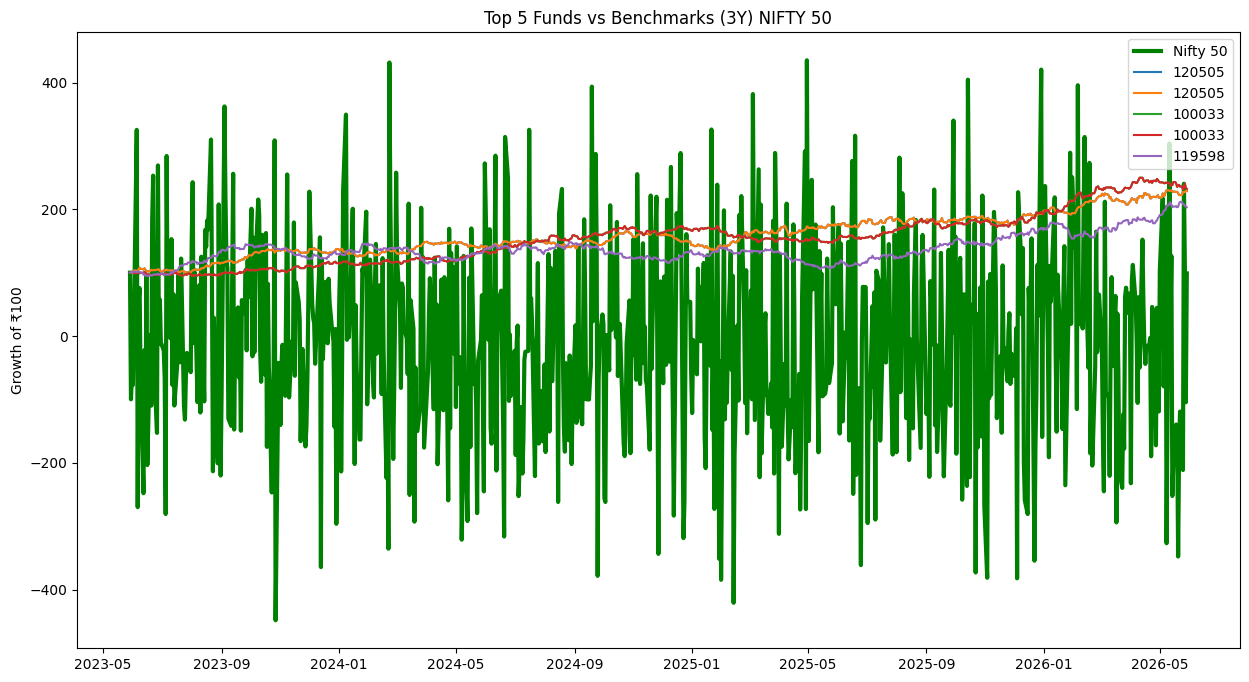

In [368]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plt.plot(
    benchmark_3y['date'],
    benchmark_3y['nifty50_growth'],
    color='green',
    linewidth=3,
    label='Nifty 50'
)

for fund in top5_funds:

    temp = plot_df[
        plot_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['growth'],
        label=fund
    )

plt.legend()
plt.title('Top 5 Funds vs Benchmarks (3Y) NIFTY 50')
plt.ylabel('Growth of ₹100')
plt.show()

plt.tight_layout()

plt.savefig(
    'C:\\Users\\Asus\\OneDrive\\Desktop\\Bluestock_intern\\Bluestock-project-repo-1\\bluestock_mf_capstone\\reports\\benchmark_plots\\benchmark_comparison_3y(NIFTY50).png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()



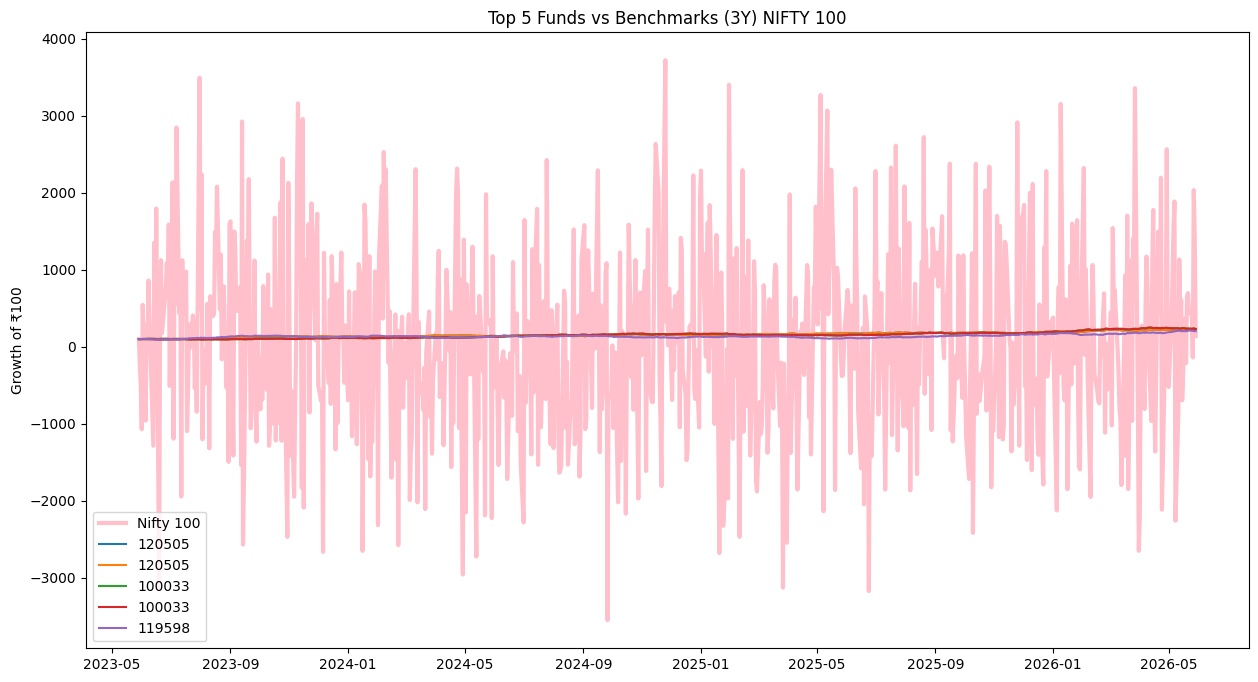

In [369]:


plt.figure(figsize=(15,8))

plt.plot(
    benchmark_3y['date'],
    benchmark_3y['nifty100_growth'],
    color= 'pink', 
    linewidth=3,
    label='Nifty 100'
)

for fund in top5_funds:

    temp = plot_df[
        plot_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['growth'],
        label=fund
    )

plt.legend()
plt.title('Top 5 Funds vs Benchmarks (3Y) NIFTY 100')
plt.ylabel('Growth of ₹100')
plt.show()

plt.tight_layout()

plt.savefig(
    'C:\\Users\\Asus\\OneDrive\\Desktop\\Bluestock_intern\\Bluestock-project-repo-1\\bluestock_mf_capstone\\reports\\benchmark_plots\\benchmark_comparison_3y(NIFTY100).png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()
